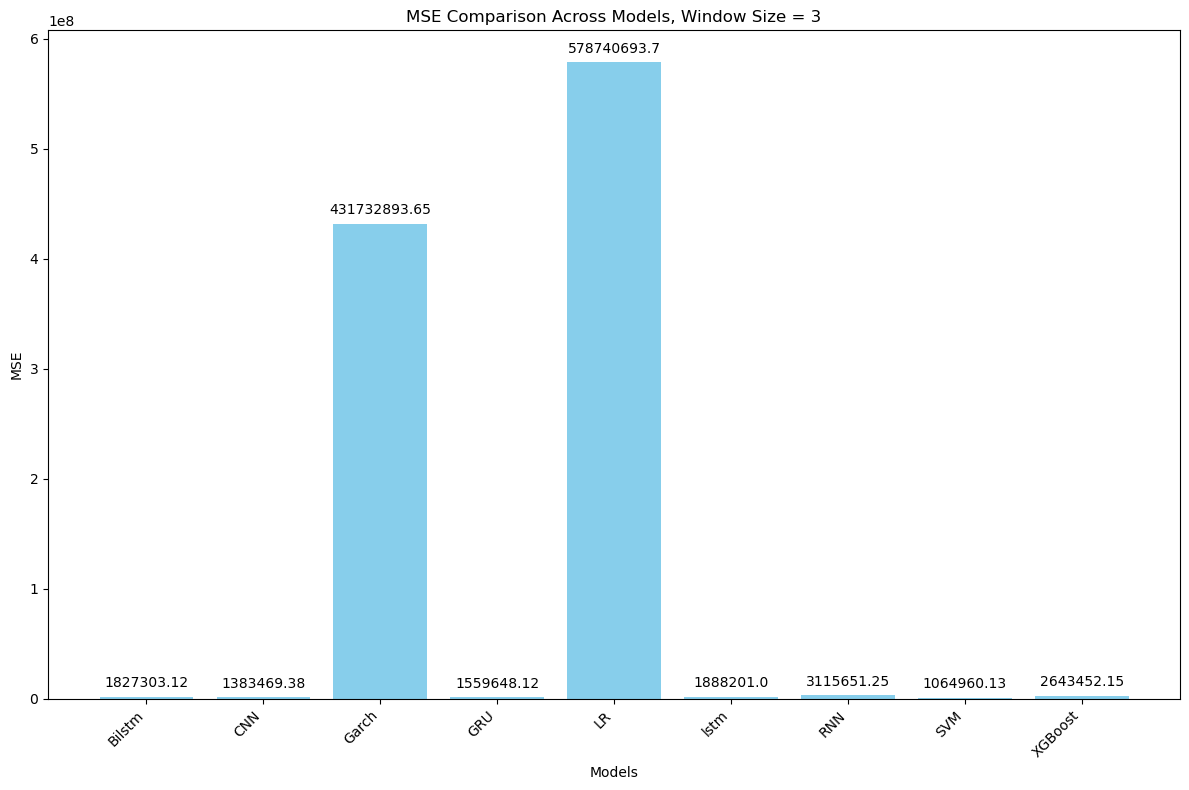

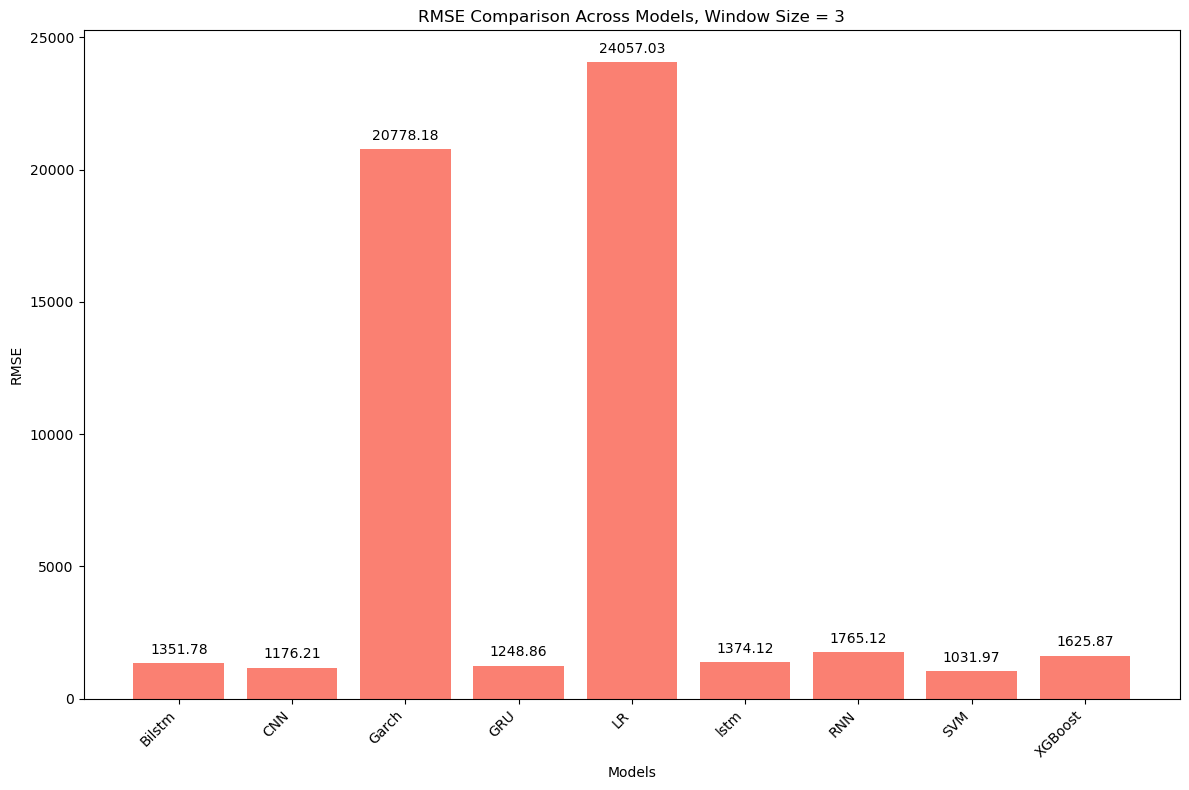

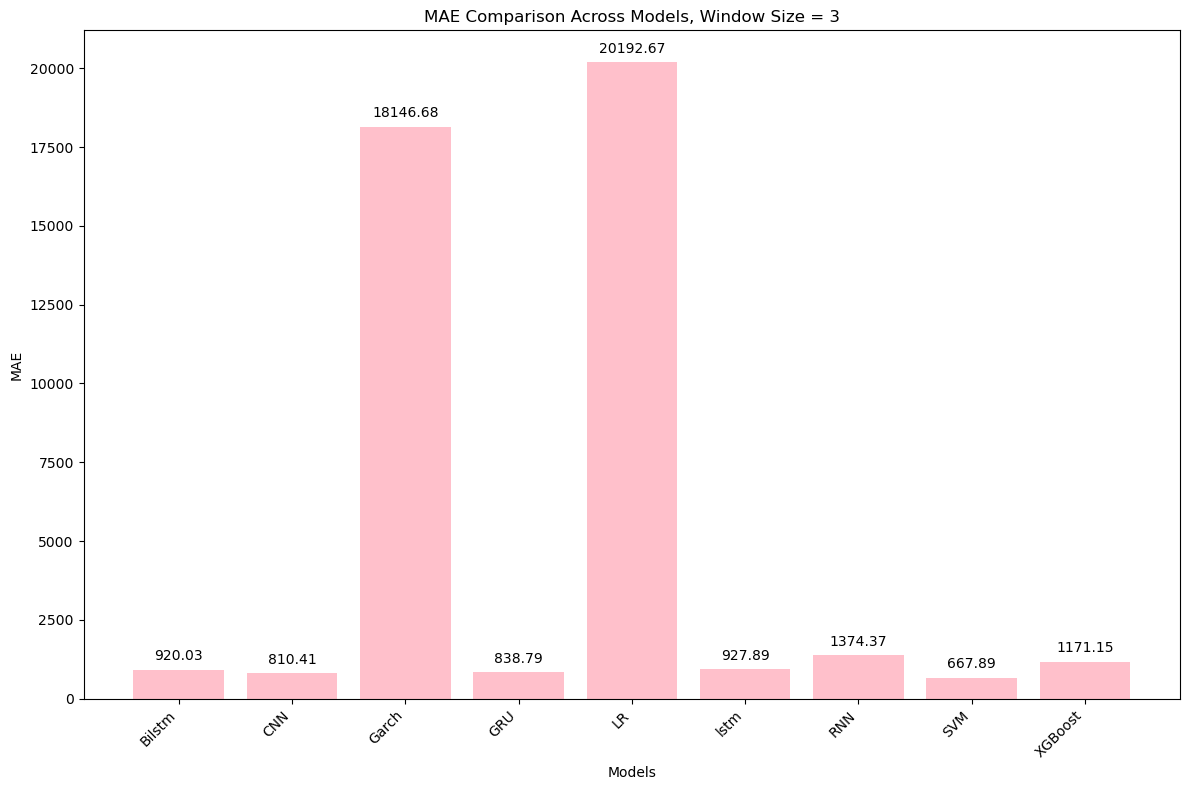

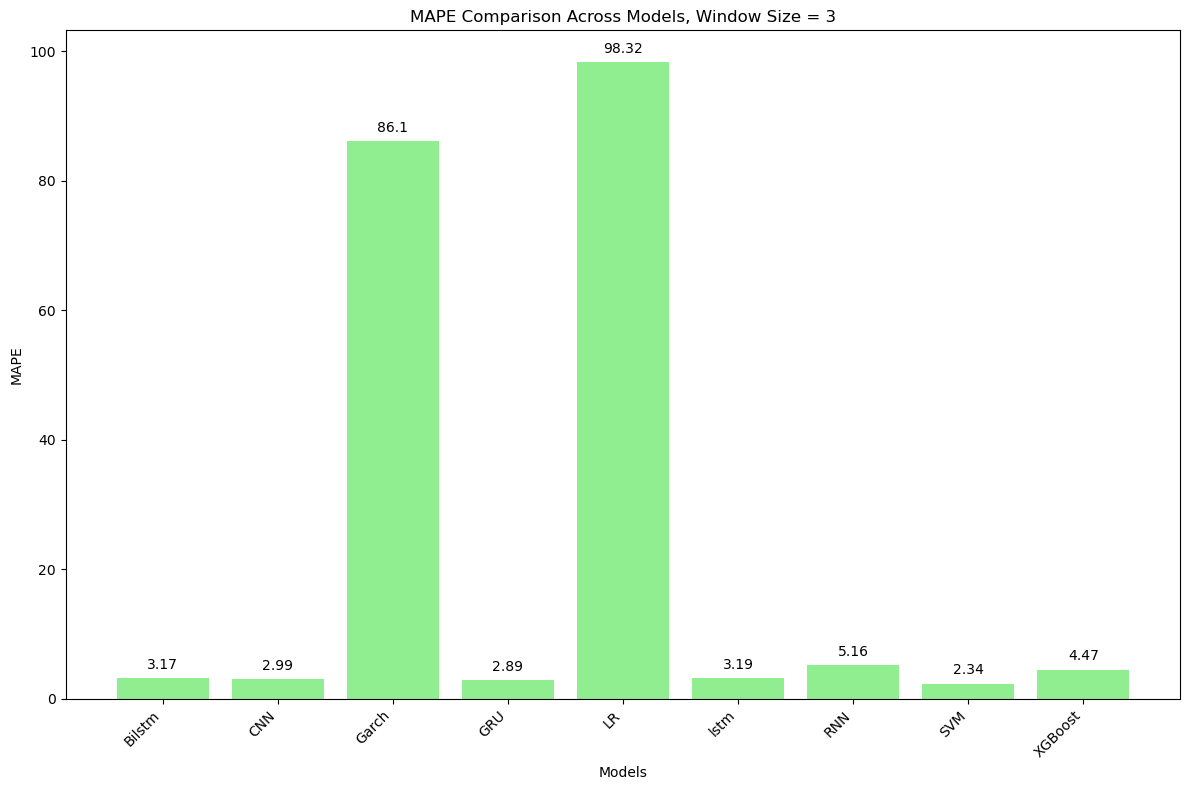

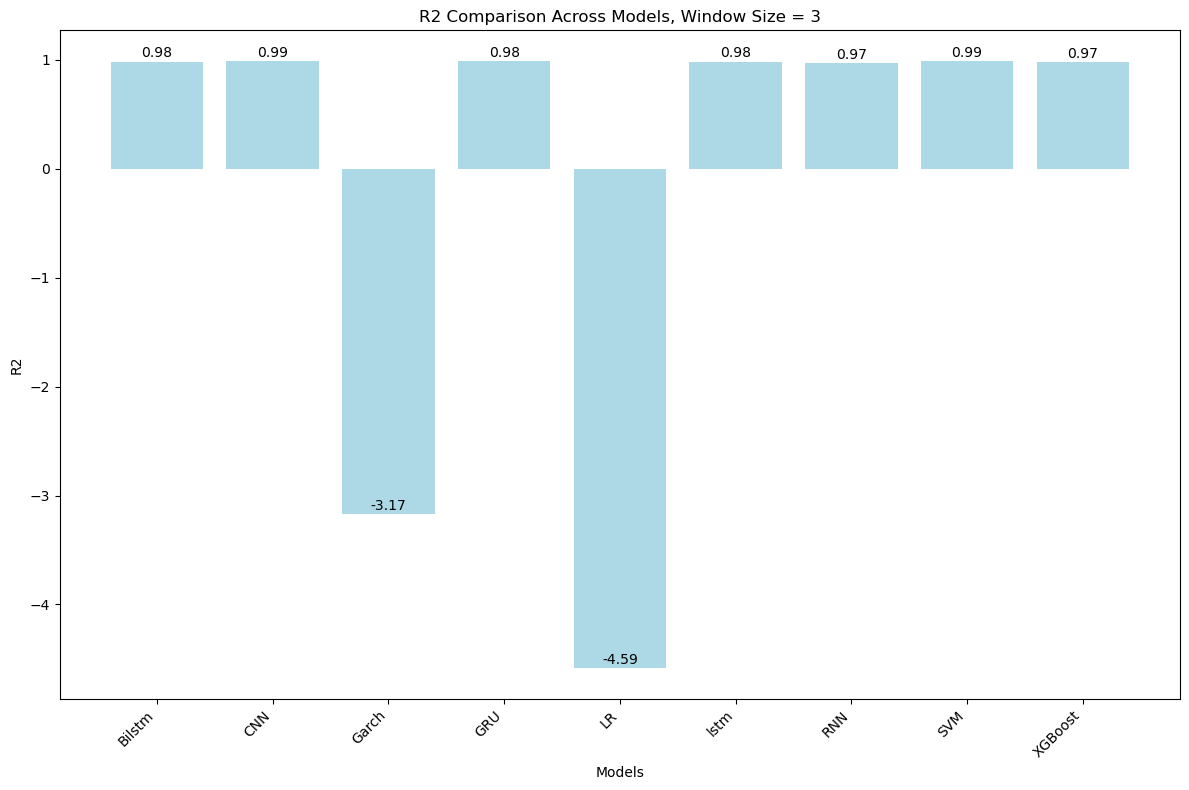

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Defining the model results
models = ['Bilstm', 'CNN', 'Garch', 'GRU', 'LR', 'lstm', 'RNN', 'SVM', 'XGBoost']
performance_data = {
    'Bilstm': [1827303.1250, 1351.7777, 920.0294, 3.1746, 0.9824],
    'CNN': [1383469.3750, 1176.2097, 810.4084, 2.9884, 0.9866],
    'Garch': [431732893.6473, 20778.1831, 18146.6840, 86.1022, -3.1671],
    'GRU': [1559648.1250, 1248.8588, 838.7874, 2.8936, 0.9849],
    'LR': [578740693.6971, 24057.0300, 20192.6713, 98.3221, -4.5861],
    'lstm': [1888201.0000, 1374.1183, 927.8859, 3.1909, 0.9818],
    'RNN': [3115651.2500, 1765.1207, 1374.3745, 5.1620, 0.9699],
    'SVM': [1064960.1314, 1031.9691, 667.8897, 2.3366, 0.9897],
    'XGBoost': [2643452.1495, 1625.8697, 1171.1462, 4.4692, 0.9745]
}

# MSE Plot
mse_values = [performance_data[model][0] for model in models]
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(models, mse_values, color='skyblue')
ax.set_xlabel('Models')
ax.set_ylabel('MSE')
ax.set_title('MSE Comparison Across Models, Window Size = 3')
plt.xticks(rotation=45, ha="right")

# Add text labels to each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01 * max(mse_values), round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# RMSE Plot
rmse_values = [performance_data[model][1] for model in models]
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(models, rmse_values, color='salmon')
ax.set_xlabel('Models')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison Across Models, Window Size = 3')
plt.xticks(rotation=45, ha="right")

# Add text labels to each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01 * max(rmse_values), round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# MAE Plot
mae_values = [performance_data[model][2] for model in models]
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(models, mae_values, color='pink')
ax.set_xlabel('Models')
ax.set_ylabel('MAE')
ax.set_title('MAE Comparison Across Models, Window Size = 3')
plt.xticks(rotation=45, ha="right")

# Add text labels to each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01 * max(mae_values), round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# MAPE Plot
mape_values = [performance_data[model][3] for model in models]
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(models, mape_values, color='lightgreen')
ax.set_xlabel('Models')
ax.set_ylabel('MAPE')
ax.set_title('MAPE Comparison Across Models, Window Size = 3')
plt.xticks(rotation=45, ha="right")

# Add text labels to each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01 * max(mape_values), round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# R2 Plot
r2_values = [performance_data[model][4] for model in models]
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(models, r2_values, color='lightblue')
ax.set_xlabel('Models')
ax.set_ylabel('R2')
ax.set_title('R2 Comparison Across Models, Window Size = 3')
plt.xticks(rotation=45, ha="right")

# Add text labels to each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01 * max(r2_values), round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from IPython.display import display, Markdown

# Model evaluation results
data = {
    'Model': ['BiLSTM', 'CNN', 'GARCH', 'GRU', 'LR', 'LSTM', 'RNN', 'SVM', 'XGBoost'],
    'MSE': [1827303.1250, 1383469.3750, 431732893.6473, 1559648.1250, 578740693.6971, 1888201.0000, 3115651.2500, 1064960.1314, 2643452.1495],
    'RMSE': [1351.7777, 1176.2097, 20778.1831, 1248.8588, 24057.0300, 1374.1183, 1765.1207, 1031.9691, 1625.8697],
    'MAE': [920.0294, 810.4084, 18146.6840, 838.7874, 20192.6713, 927.8859, 1374.3745, 667.8897, 1171.1462],
    'MAPE': [3.1746, 2.9884, 86.1022, 2.8936, 98.3221, 3.1909, 5.1620, 2.3366, 4.4692],
    'R2': [0.9824, 0.9866, -3.1671, 0.9849, -4.5861, 0.9818, 0.9699, 0.9897, 0.9745]
}


df = pd.DataFrame(data)
rank_df = df.copy()

# Rank (lower is better for most, higher is better for R2)
for metric in ['MSE', 'RMSE', 'MAE', 'MAPE']:
    rank_df[metric + '_Rank'] = df[metric].rank(method='min', ascending=True).astype(int)
rank_df['R2_Rank'] = df['R2'].rank(method='min', ascending=False).astype(int)

# Average ranking score (1 decimal)
rank_df['Total_Score (Lower is better for overall performance)'] = rank_df[
    ['MSE_Rank', 'RMSE_Rank', 'MAE_Rank', 'MAPE_Rank', 'R2_Rank']
].mean(axis=1)

# Final ranking
rank_df = rank_df.sort_values(by='Total_Score (Lower is better for overall performance)').reset_index(drop=True)
rank_df['Final_Rank'] = rank_df.index + 1

# Display table with formatted score (1 decimal)
final_rank = rank_df[[ 
    'Final_Rank', 'Model', 
    'MSE_Rank', 'RMSE_Rank', 'MAE_Rank', 'MAPE_Rank', 'R2_Rank', 
    'Total_Score (Lower is better for overall performance)' 
]]

display(Markdown("**📊 Univariate Model Ranking, Window Size = 3**"))
display(
    final_rank.style
        .hide(axis='index')
        .format({
            'Total_Score (Lower is better for overall performance)': '{:.1f}'
        })
)


**📊 Univariate Model Ranking, Window Size = 3**

Final_Rank,Model,MSE_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,R2_Rank,Total_Score (Lower is better for overall performance)
1,SVM,1,1,1,1,1,1.0
2,CNN,2,2,2,3,2,2.2
3,GRU,3,3,3,2,3,2.8
4,BiLSTM,4,4,4,4,4,4.0
5,LSTM,5,5,5,5,5,5.0
6,XGBoost,6,6,6,6,6,6.0
7,RNN,7,7,7,7,7,7.0
8,GARCH,8,8,8,8,8,8.0
9,LR,9,9,9,9,9,9.0
